In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style="whitegrid")

warnings.filterwarnings("ignore")

In [ ]:
DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset.csv"

dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

## Univariate Analysis

In [ ]:
def plot_numerical_distribution_plot(df, title=None, stat="count"):
    fig, axs = plt.subplots(4, 2, figsize=(20, 20))
    plt.subplots_adjust(hspace=0.3)

    if title: plt.suptitle(title, fontsize=20)

    sns.histplot(data=df, x="Accelerometer1RMS", kde=True, ax=axs[0, 0], hue="description", stat=stat)
    axs[0, 0].set_title("Distribution of Accelerometer1RMS")

    sns.histplot(data=df, x="Accelerometer2RMS", kde=True, ax=axs[0, 1], hue="description", stat=stat)
    axs[0, 1].set_title("Distribution of Accelerometer2RMS")

    sns.histplot(data=df, x="Current", kde=True, ax=axs[1, 0], hue="description", stat=stat)
    axs[1, 0].set_title("Distribution of Current")

    sns.histplot(data=df, x="Voltage", kde=True, ax=axs[1, 1], hue="description", stat=stat)
    axs[1, 1].set_title("Distribution of Voltage")

    sns.histplot(data=df, x="Pressure", kde=True, ax=axs[2, 0], hue="description", stat=stat)
    axs[2, 0].set_title("Distribution of Pressure")

    sns.histplot(data=df, x="Volume Flow RateRMS", kde=True, ax=axs[2, 1], hue="description", stat=stat)
    axs[2, 1].set_title("Distribution of Volume Flow RateRMS")

    sns.histplot(data=df, x="Temperature", kde=True, ax=axs[3, 0], hue="description", stat=stat)
    axs[3, 0].set_title("Distribution of Temperature")

    sns.histplot(data=df, x="Thermocouple", kde=True, ax=axs[3, 1], hue="description", stat=stat)
    axs[3, 1].set_title("Distribution of Thermocouple")

    plt.tight_layout()

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [ ]:
plot_numerical_distribution_plot(dataframe["2020-02-08 00:00:00":"2020-02-08 23:59:59"], title="Distribution of Parameters (2020-02-08)", stat="percent")
plot_numerical_distribution_plot(dataframe["2020-03-01 00:00:00":"2020-03-01 23:59:59"], title="Distribution of Parameters (2020-03-01)", stat="percent")
plot_numerical_distribution_plot(dataframe["2020-03-09 00:00:00":"2020-03-09 23:59:59"], title="Distribution of Parameters (2020-03-09)", stat="percent")

In [ ]:
def plot_categorical_distribution_plot(dataframe, column_name, title=None):
    """
    Plots the distribution of a categorical column with counts on top of bars.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
        title (str, optional): The title of the plot. Defaults to None.
    """
    plt.figure(figsize=(15, 6)) # Adjusted figure size for better readability
    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    # Create the countplot
    ax = sns.countplot(y=column_name, data=dataframe, order=dataframe[column_name].value_counts().index, palette='viridis', stat="percent")

    # Add count labels on top of each bar
    for p in ax.patches:
        width = p.get_width()    # Get the width of the bar (which is the count)
        plt.text(width + 0.5,     # Set the x position of the text slightly to the right of the bar
                 p.get_y() + p.get_height() / 2, # Set the y position at the middle of the bar
                 '{:0.2f}%'.format(width), # Format the count to an integer
                 ha='left', va='center', fontsize=10, color='black') # Text alignment and style

    plt.xlabel('Count', fontsize=12) # Label for x-axis
    plt.ylabel(column_name.replace('_', ' ').title(), fontsize=12) # Formatted label for y-axis
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [ ]:
plot_categorical_distribution_plot(dataframe, column_name="description", title="Distribution of Anomalies")

## Bivariate Analysis

In [ ]:
def plot_box(df, title=None):
    fig, axs = plt.subplots(8, 1, figsize=(20, 60))
    # plt.subplots_adjust(hspace=0.5)

    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    sns.boxplot(x="Accelerometer1RMS", y="description", data=df, hue="description", ax=axs[0])
    axs[0].set_title("Distribution of Accelerometer1RMS", weight="bold")

    sns.boxplot(x="Accelerometer2RMS", y="description", data=df, hue="description", ax=axs[1])
    axs[1].set_title("Distribution of Accelerometer2RMS", weight="bold")

    sns.boxplot(x="Current", y="description", data=df, hue="description", ax=axs[2])
    axs[2].set_title("Distribution of Current", weight="bold")

    sns.boxplot(x="Voltage", y="description", data=df, hue="description", ax=axs[3])
    axs[3].set_title("Distribution of Voltage", weight="bold")

    sns.boxplot(x="Pressure", y="description", data=df, hue="description", ax=axs[4])
    axs[4].set_title("Distribution of Pressure", weight="bold")

    sns.boxplot(x="Volume Flow RateRMS", y="description", data=df, hue="description", ax=axs[5])
    axs[5].set_title("Distribution of Volume Flow RateRMS", weight="bold")

    sns.boxplot(x="Temperature", y="description", data=df, hue="description", ax=axs[6])
    axs[6].set_title("Distribution of Temperature", weight="bold")

    sns.boxplot(x="Thermocouple", y="description", data=df, hue="description", ax=axs[7])
    axs[7].set_title("Distribution of Thermocouple", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

def plot_violin(df, title=None):
    fig, axs = plt.subplots(8, 1, figsize=(20, 60))
    # plt.subplots_adjust(hspace=0.5)

    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    sns.violinplot(x="Accelerometer1RMS", y="description", data=df, hue="description", ax=axs[0])
    axs[0].set_title("Distribution of Accelerometer1RMS", weight="bold")

    sns.violinplot(x="Accelerometer2RMS", y="description", data=df, hue="description", ax=axs[1])
    axs[1].set_title("Distribution of Accelerometer2RMS", weight="bold")

    sns.violinplot(x="Current", y="description", data=df, hue="description", ax=axs[2])
    axs[2].set_title("Distribution of Current", weight="bold")

    sns.violinplot(x="Voltage", y="description", data=df, hue="description", ax=axs[3])
    axs[3].set_title("Distribution of Voltage", weight="bold")

    sns.violinplot(x="Pressure", y="description", data=df, hue="description", ax=axs[4])
    axs[4].set_title("Distribution of Pressure", weight="bold")

    sns.violinplot(x="Volume Flow RateRMS", y="description", data=df, hue="description", ax=axs[5])
    axs[5].set_title("Distribution of Volume Flow RateRMS", weight="bold")

    sns.violinplot(x="Temperature", y="description", data=df, hue="description", ax=axs[6])
    axs[6].set_title("Distribution of Temperature", weight="bold")

    sns.violinplot(x="Thermocouple", y="description", data=df, hue="description", ax=axs[7])
    axs[7].set_title("Distribution of Thermocouple", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [ ]:
plot_box(dataframe, title="Numerical Fearures vs Faulty Status (Box Plot)")
plot_violin(dataframe, title="Numerical Fearures vs Faulty Status (Violin Plot)")

In [ ]:
def plot_anomaly_heatmap(df, columns, title=None):
    fig, axs = plt.subplots(7, 2, figsize=(20, 56), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.3)

    if title: plt.suptitle(title, fontsize=20)

    sns.heatmap(df.iloc[np.where(df.anomaly==0.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[0, 0])
    axs[0, 0].set_title("Heatmap of 'No Anomaly'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==1.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[0, 1])
    axs[0, 1].set_title("Heatmap of 'Sharp - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==2.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[1, 0])
    axs[1, 0].set_title("Heatmap of 'Linear - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==3.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[1, 1])
    axs[1, 1].set_title("Heatmap of 'Step - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==4.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[2, 0])
    axs[2, 0].set_title("Heatmap of 'Dirac - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==5.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[2, 1])
    axs[2, 1].set_title("Heatmap of 'Exponential - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==6.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[3, 0])
    axs[3, 0].set_title("Heatmap of 'Slow Water Increase (Circuit)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==7.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[3, 1])
    axs[3, 1].set_title("Heatmap of 'Sharp Water Increase (Circuit)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==8.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[4, 0])
    axs[4, 0].set_title("Heatmap of 'Water Drainage (Cavitation)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==9.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[4, 1])
    axs[4, 1].set_title("Heatmap of 'Two-phase Supply (Cavitation)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==10.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[5, 0])
    axs[5, 0].set_title("Heatmap of 'Water Temperature Increase'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==11.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[5, 1])
    axs[5, 1].set_title("Heatmap of 'Fluid Leaks'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==12.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[6, 0])
    axs[6, 0].set_title("Heatmap of 'Inlet Valve Malfunction'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==13.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[6, 1])
    axs[6, 1].set_title("Heatmap of 'Outlet Valve Malfunction'", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [ ]:
columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]
plot_anomaly_heatmap(dataframe, columns, title="Correlation Between Parameters")

## Multivariate Analysis

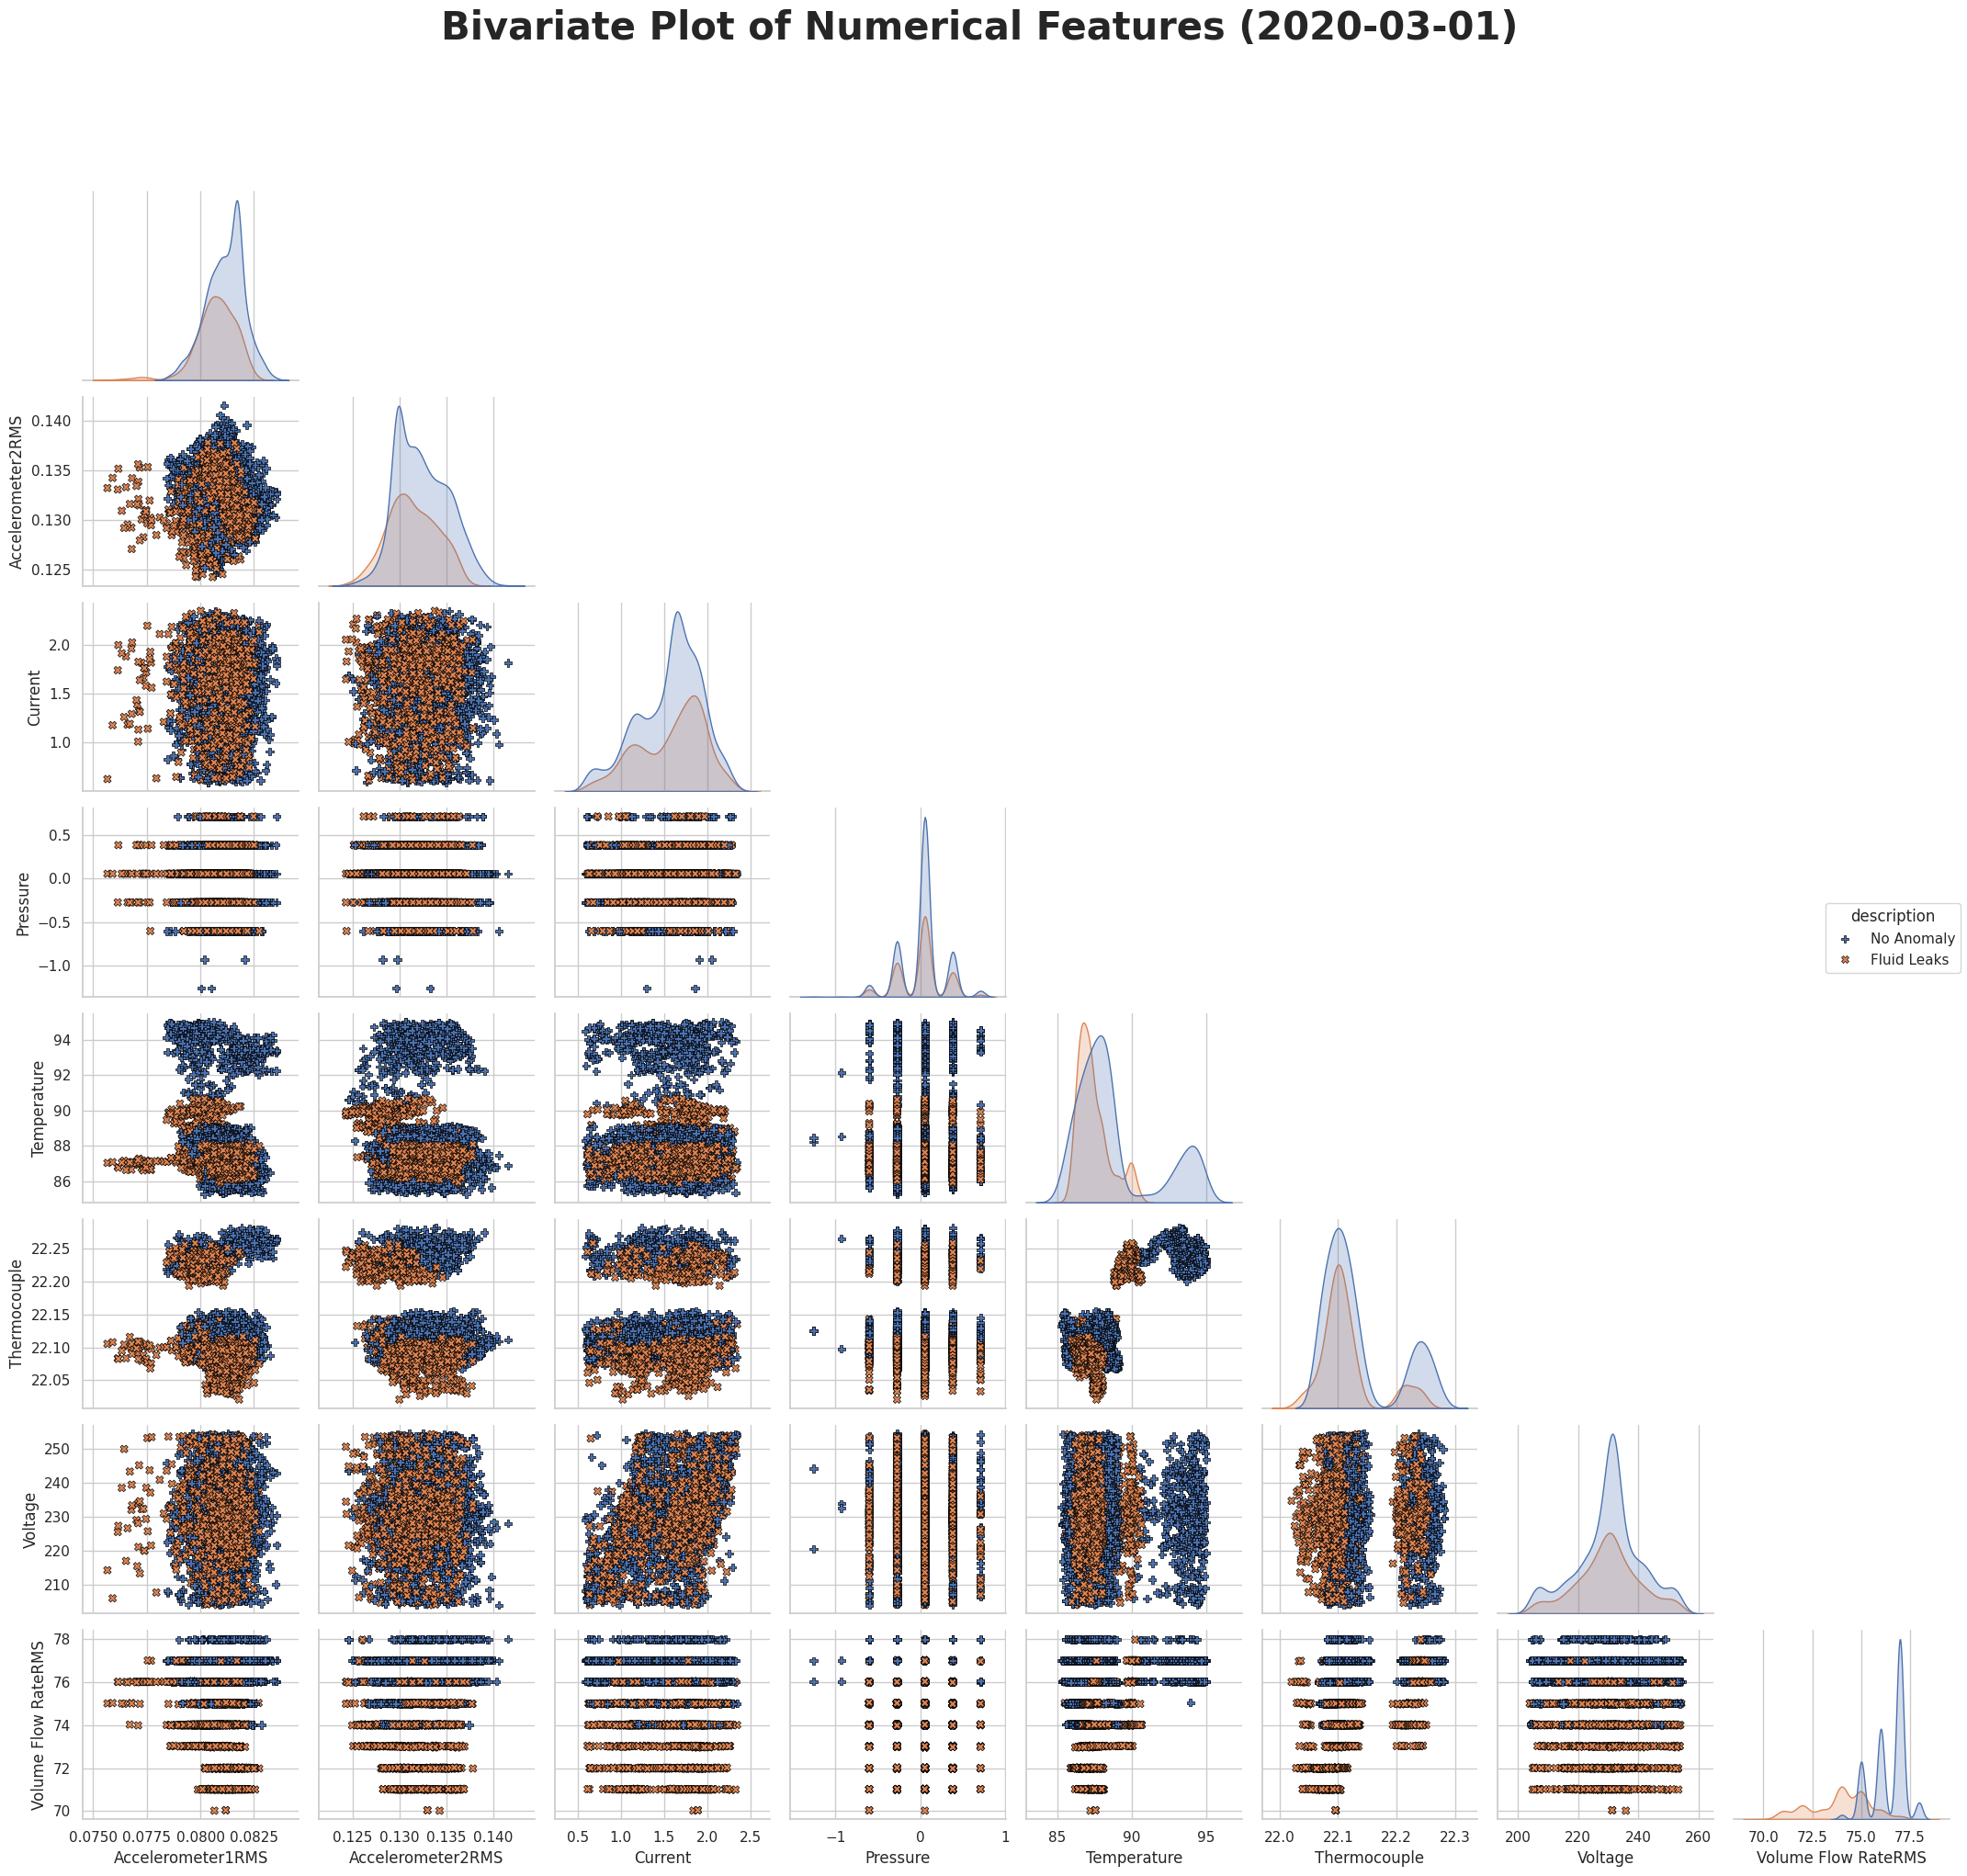

In [ ]:
def plot_pairplot(df, columns, title=None):
    """
    Plots a pairplot of the given dataframe with specified columns and hue.
    
    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
    """
    ax = sns.pairplot(
                        data = df, 
                        hue="description", 
                        hue_order=df["description"].value_counts().index, 
                        vars=columns, 
                        corner=True, 
                        plot_kws={'edgecolor': 'black'},
                        markers=['P', 'X', 'o', 'v', '^', '<', '>', 'h', 'H', 'D', 'd', 's', 'p', '8'],
    )
    sns.move_legend(ax, "center right", ncol=1, title="description", frameon=True)
    ax.fig.suptitle(title, y=1.02, weight="bold", fontsize=30) # Adjust y for vertical positioning

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]  
plot_pairplot(dataframe["2020-02-08 00:00:00":"2020-02-08 23:59:59"], columns, title="Bivariate Plot of Numerical Features (2020-02-08)")
plot_pairplot(dataframe["2020-03-01 00:00:00":"2020-03-01 23:59:59"], columns, title="Bivariate Plot of Numerical Features (2020-03-01)")
plot_pairplot(dataframe["2020-03-09 00:00:00":"2020-03-09 23:59:59"], columns, title="Bivariate Plot of Numerical Features (2020-03-09)")

In [ ]:
def plot_box2(df, xaxis, columns, hue=None, title=None):
    fig, axs = plt.subplots(len(columns), 1, figsize=(20, len(columns)*8), sharex=False)
    # plt.subplots_adjust(hspace=0.5)

    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    for ax, yaxis in enumerate(columns):
        p = sns.boxplot(x=xaxis, y=yaxis, data=df, hue=hue, ax=axs[ax])
        axs[ax].set_title(f"Distribution of {yaxis}", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [ ]:
columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            # "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]   
plot_box2(dataframe, xaxis="Pressure", columns=columns, hue="description", title="Numerical Feature vs Pressure vs Anomaly")

## Time Series Analysis

In [ ]:
def plot_timeseries_with_anomaly(df, columns, title=None):
    fig, axs = plt.subplots(len(columns), 1, figsize=(20, len(columns)*6), sharex=False)
    # plt.subplots_adjust(hspace=0.5)

    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    for ax, column in enumerate(columns):
        sns.lineplot(data=df, x=df.index, y=column, alpha=0.6, label=column, ax=axs[ax])
        axs[ax].set_title(f"Time Series of {column}", weight="bold")

        faulty_points = df[df["anomaly"]!=0.0]
        sns.scatterplot(data=faulty_points, x=faulty_points.index, y=column, hue="description", style="description", edgecolor="black", zorder=5, ax=axs[ax])

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [ ]:
columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]   
plot_timeseries_with_anomaly(
                                dataframe["2020-02-08 00:00:00":"2020-02-08 23:59:59"], 
                                columns=columns, 
                                title="Numerical Parameters with Highlighted Anomalies (2020-02-08)"
)   
plot_timeseries_with_anomaly(
                                dataframe["2020-03-01 00:00:00":"2020-03-01 23:59:59"], 
                                columns=columns, 
                                title="Numerical Parameters with Highlighted Anomalies (2020-03-01)"
)   
plot_timeseries_with_anomaly(
                                dataframe["2020-03-09 00:00:00":"2020-03-09 23:59:59"], 
                                columns=columns, 
                                title="Numerical Parameters with Highlighted Anomalies (2020-03-09)"
)